In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# 1. Load Iris dataset into a Pandas DataFrame
iris_data = load_iris()
df = pd.DataFrame(data=iris_data.data, columns=iris_data.feature_names)
df['species'] = pd.Categorical.from_codes(iris_data.target, iris_data.target_names)

# 2. Dataset Overview & Properties
print("--- DATASET OVERVIEW ---")
print(f"Number of Records (Rows): {df.shape[0]}")
print(f"Number of Features (Columns): {df.shape[1] - 1}") # Excluding target column
print(f"Feature Names: {list(df.columns[:-1])}")
print(f"Target / Class Variable: 'species' with unique values {df['species'].unique().tolist()}")
print("\n--- DATA TYPES ---")
print(df.dtypes)

print("\n--- BASIC STATISTICAL INFORMATION (Pandas) ---")
print(df.describe())

--- DATASET OVERVIEW ---
Number of Records (Rows): 150
Number of Features (Columns): 4
Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target / Class Variable: 'species' with unique values ['setosa', 'versicolor', 'virginica']

--- DATA TYPES ---
sepal length (cm)     float64
sepal width (cm)      float64
petal length (cm)     float64
petal width (cm)      float64
species              category
dtype: object

--- BASIC STATISTICAL INFORMATION (Pandas) ---
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.

In [2]:
# Convert features to NumPy array for numerical operations
feature_matrix = df.iloc[:, :-1].to_numpy()

# Calculate statistics per feature (axis=0 operates column-wise)
means = np.mean(feature_matrix, axis=0)
mins = np.min(feature_matrix, axis=0)
maxs = np.max(feature_matrix, axis=0)
std_devs = np.std(feature_matrix, axis=0)

stats_df = pd.DataFrame({
    'Feature': iris_data.feature_names,
    'Mean': np.round(means, 2),
    'Minimum': np.round(mins, 2),
    'Maximum': np.round(maxs, 2),
    'Standard Deviation': np.round(std_devs, 2)
})

print("--- NUMPY STATISTICAL MEASURES ---")
print(stats_df.to_string(index=False))

--- NUMPY STATISTICAL MEASURES ---
          Feature  Mean  Minimum  Maximum  Standard Deviation
sepal length (cm)  5.84      4.3      7.9                0.83
 sepal width (cm)  3.06      2.0      4.4                0.43
petal length (cm)  3.76      1.0      6.9                1.76
 petal width (cm)  1.20      0.1      2.5                0.76


In [3]:
# 1. Selecting relevant columns
sepal_data = df[['sepal length (cm)', 'sepal width (cm)', 'species']]

# 2. Filtering records (Example: Petal length greater than 5.0 cm)
large_petals = df[df['petal length (cm)'] > 5.0]

# 3. Grouping data by species class and calculating summary statistics
grouped_stats = df.groupby('species', observed=False).agg(['mean', 'std'])

print("\n--- GROUP-WISE MEAN AND STANDARD DEVIATION BY SPECIES ---")
print(np.round(grouped_stats, 2))


--- GROUP-WISE MEAN AND STANDARD DEVIATION BY SPECIES ---
           sepal length (cm)       sepal width (cm)       petal length (cm)  \
                        mean   std             mean   std              mean   
species                                                                       
setosa                  5.01  0.35             3.43  0.38              1.46   
versicolor              5.94  0.52             2.77  0.31              4.26   
virginica               6.59  0.64             2.97  0.32              5.55   

                 petal width (cm)        
             std             mean   std  
species                                  
setosa      0.17             0.25  0.11  
versicolor  0.47             1.33  0.20  
virginica   0.55             2.03  0.27  


C:\Users\sys\AppData\Local\Temp\ipykernel_17308\2168239394.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(data_to_plot, labels=species_list)


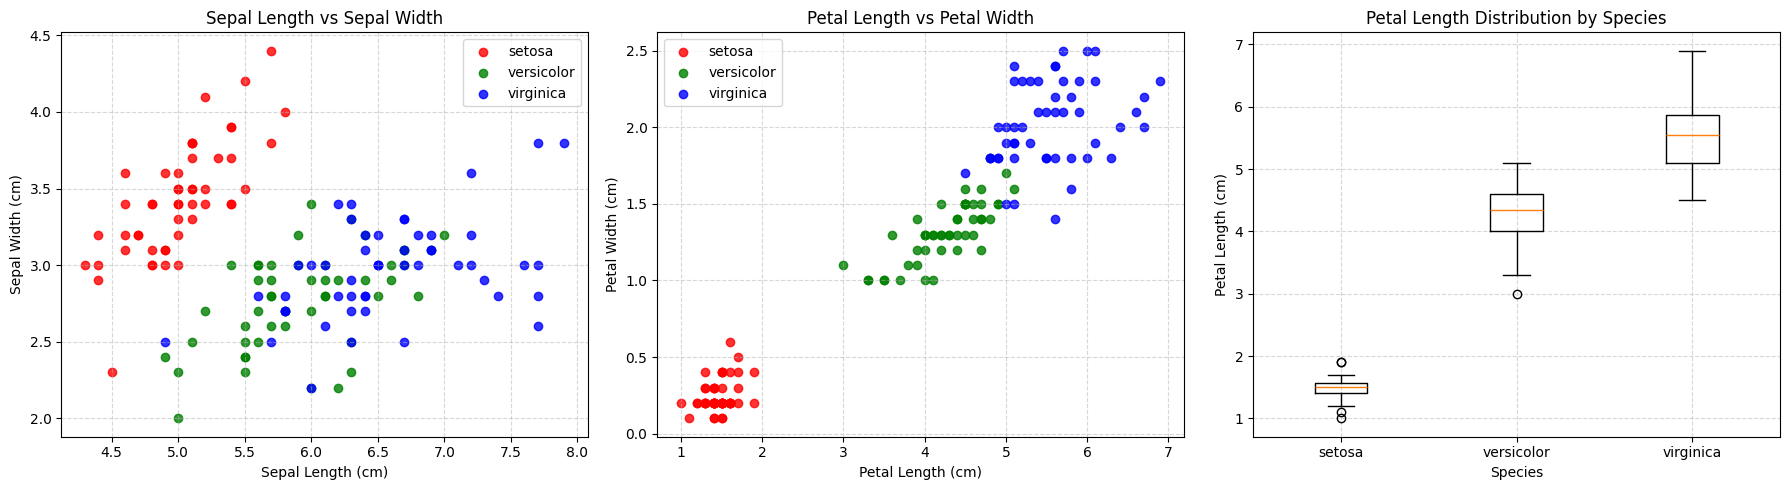

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Visualization 1: Scatter Plot (Sepal Length vs. Sepal Width)
colors = {'setosa': 'red', 'versicolor': 'green', 'virginica': 'blue'}
for species, group in df.groupby('species', observed=False):
    axes[0].scatter(group['sepal length (cm)'], group['sepal width (cm)'], 
                    label=species, alpha=0.8, color=colors[species])
axes[0].set_title('Sepal Length vs Sepal Width')
axes[0].set_xlabel('Sepal Length (cm)')
axes[0].set_ylabel('Sepal Width (cm)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Visualization 2: Scatter Plot (Petal Length vs. Petal Width)
for species, group in df.groupby('species', observed=False):
    axes[1].scatter(group['petal length (cm)'], group['petal width (cm)'], 
                    label=species, alpha=0.8, color=colors[species])
axes[1].set_title('Petal Length vs Petal Width')
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

# Visualization 3: Box Plot for Petal Length Distribution by Species
species_list = df['species'].unique()
data_to_plot = [df[df['species'] == sp]['petal length (cm)'] for sp in species_list]
axes[2].boxplot(data_to_plot, labels=species_list)
axes[2].set_title('Petal Length Distribution by Species')
axes[2].set_xlabel('Species')
axes[2].set_ylabel('Petal Length (cm)')
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Input Features (X): Continuous numerical matrix of dimensions $(150, 4)$ containing sepal length (cm), sepal width (cm), petal length (cm), and petal width (cm).
Target Variable (y): Categorical class label species (setosa, versicolor, virginica).
 Supervised Problem Type: Multi-class Classification.
 Unsupervised Problem Type: Clustering / Pattern Discovery.
  Expected Output:  
Supervised: Predicted categorical label for an unseen sample.
Unsupervised: Cluster groupings/assignments ($C_1, C_2, C_3$) without prior class knowledge.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Separate Input Features (X) and Target Label (y)
X = df.iloc[:, :-1].values
y = iris_data.target

# 2. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Supervised Model Execution (K-Nearest Neighbors Classifier)
clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("--- SUPERVISED LEARNING RESULTS ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=iris_data.target_names))

--- SUPERVISED LEARNING RESULTS ---
Accuracy Score: 100.00%

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



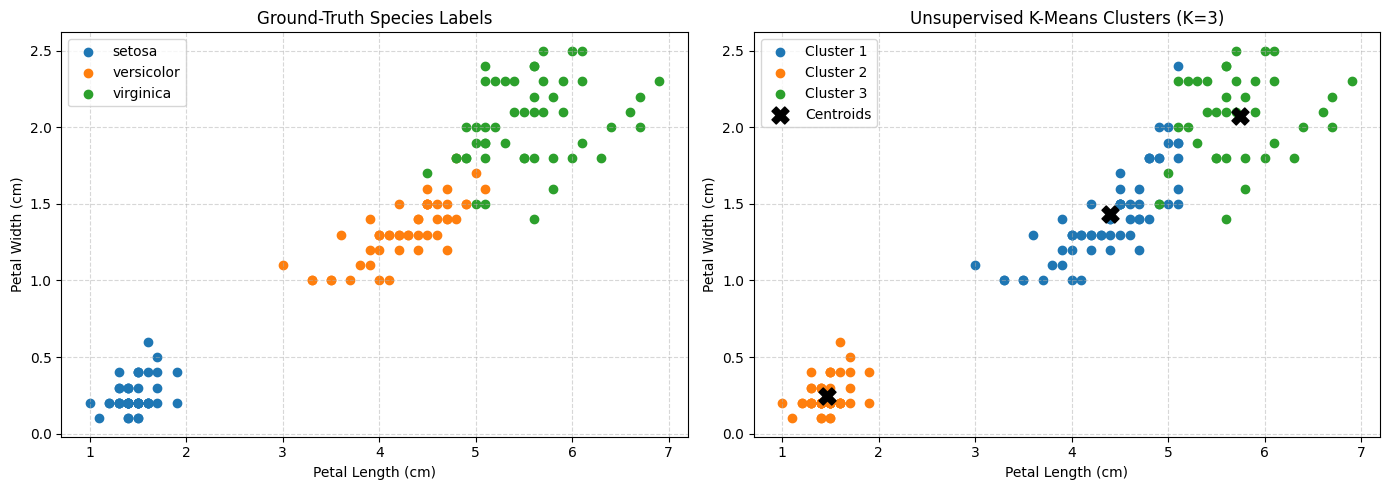

In [6]:
from sklearn.cluster import KMeans

# Unsupervised execution (X matrix used strictly without ground-truth y)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

# Visualization comparison: True Labels vs Unsupervised KMeans Clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot True Labels
for species_idx, species_name in enumerate(iris_data.target_names):
    axes[0].scatter(X[y == species_idx, 2], X[y == species_idx, 3], label=species_name)
axes[0].set_title('Ground-Truth Species Labels')
axes[0].set_xlabel('Petal Length (cm)')
axes[0].set_ylabel('Petal Width (cm)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot Unsupervised Clusters
for cluster_idx in range(3):
    axes[1].scatter(X[cluster_labels == cluster_idx, 2], X[cluster_labels == cluster_idx, 3], 
                    label=f'Cluster {cluster_idx + 1}')
axes[1].scatter(kmeans.cluster_centers_[:, 2], kmeans.cluster_centers_[:, 3], 
                color='black', marker='X', s=150, label='Centroids')
axes[1].set_title('Unsupervised K-Means Clusters (K=3)')
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()